In [157]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


 Carga de los datasets

In [188]:
df_artistas=pd.read_csv("data/artists.csv")
df_escuchas=pd.read_csv("data/listeners.csv")
df_mas_streams=pd.read_csv("data/Spotify_most_streamed.csv")


Exploración inicial 

In [159]:
df_artistas.head()


,Artist,Streams,Daily,As lead,Solo,As feature
0,Drake,"85,041.3",50.775,"57,252.6","32,681.6","27,788.7"
1,Bad Bunny,"67,533.0",44.820,"40,969.6","23,073.0","26,563.4"
2,Taylor Swift,"57,859.0",85.793,"55,566.7","50,425.7","2,292.4"
3,The Weeknd,"53,665.2",44.437,"42,673.3","31,164.2","10,991.9"
4,Ed Sheeran,"47,907.7",17.506,"42,767.9","33,917.0","5,139.8"


In [189]:
df_escuchas.head()


,Artist,Listeners,Daily Trend,Peak,PkListeners
0,The Weeknd,"107,592,328","-138,880",1,"113,034,886"
1,Taylor Swift,"101,003,302",889,2,"101,003,302"
2,Ed Sheeran,"76,475,126","-68,137",2,"87,934,910"
3,Dua Lipa,"76,421,916","-71,356",4,"77,778,397"
4,Bad Bunny,"76,162,057","-199,052",3,"83,950,570"


In [190]:
df_mas_streams.head()

,Artist and Title,Streams,Daily
0,The Weeknd - Blinding Lights,"3,783,983,806","1,736,378"
1,Ed Sheeran - Shape of You,"3,616,649,759","1,135,140"
2,Lewis Capaldi - Someone You Loved,"2,958,875,491","1,522,093"
3,Post Malone - Sunflower,"2,898,311,408","1,871,177"
4,Tones And I - Dance Monkey,"2,896,024,418","666,818"


In [191]:
print(df_escuchas.columns)
print(df_mas_streams.columns)
print(df_artistas.columns)  

Index(['Artist', 'Listeners', 'Daily Trend', 'Peak', 'PkListeners'], dtype='str')
Index(['Artist and Title', 'Streams', 'Daily'], dtype='str')
Index(['Artist', 'Streams', 'Daily', 'As lead', 'Solo', 'As feature'], dtype='str')


Limpieza de espacios 

In [192]:
df_artistas.columns = df_artistas.columns.str.strip()
df_escuchas.columns = df_escuchas.columns.str.strip()
df_mas_streams.columns = df_mas_streams.columns.str.strip()

Verificación de valores nulos 

In [193]:
print(df_artistas.isnull().sum())
print(df_escuchas.isnull().sum())
print(df_mas_streams.isnull().sum())

Artist          0
Streams         0
Daily           6
As lead        16
Solo           69
As feature    338
dtype: int64
Artist         0
Listeners      0
Daily Trend    0
Peak           0
PkListeners    0
dtype: int64
Artist and Title    0
Streams             0
Daily               3
dtype: int64


- Se remplazan los valores nulos por 0 en el dataframe de artistas
- Se eliminan las filas con valores nulos en el dataframe de mas_streams

In [194]:
df_artistas = df_artistas.fillna(0)
df_mas_streams=df_mas_streams.dropna()

Separar la columna artist and title del dataframe df_mas_streams para realizar el analisis por separado

In [195]:
df_mas_streams[['Artist','Title']] = df_mas_streams['Artist and Title'].str.split(' - ', n=1, expand=True)

In [196]:
df_mas_streams.head(10)

,Artist and Title,Streams,Daily,Artist,Title
0,The Weeknd - Blinding Lights,"3,783,983,806","1,736,378",The Weeknd,Blinding Lights
1,Ed Sheeran - Shape of You,"3,616,649,759","1,135,140",Ed Sheeran,Shape of You
2,Lewis Capaldi - Someone You Loved,"2,958,875,491","1,522,093",Lewis Capaldi,Someone You Loved
3,Post Malone - Sunflower,"2,898,311,408","1,871,177",Post Malone,Sunflower
4,Tones And I - Dance Monkey,"2,896,024,418","666,818",Tones And I,Dance Monkey
5,Drake - One Dance,"2,770,548,672","1,461,772",Drake,One Dance
6,Post Malone - rockstar,"2,763,808,309","821,331",Post Malone,rockstar
7,The Kid LAROI - STAY,"2,738,183,590","1,490,471",The Kid LAROI,STAY
8,The Weeknd - Starboy,"2,658,550,411","2,205,639",The Weeknd,Starboy
9,Imagine Dragons - Believer,"2,654,895,028","1,346,642",Imagine Dragons,Believer


Se cambia el tipo de variable de String a int de las columnas Streams y Daily

In [197]:
df_mas_streams['Streams'] = df_mas_streams['Streams'].str.replace(',', '')
df_mas_streams['Streams'] = pd.to_numeric(df_mas_streams['Streams'])

In [198]:
df_mas_streams['Daily']=df_mas_streams['Daily'].str.replace(',', '')
df_mas_streams['Daily'] = pd.to_numeric(df_mas_streams['Daily'])

Análisis exploratorio de datos (EDA)

En esta etapa se analizan los datos para identificar patrones y relaciones importantes.

Se busca responder preguntas como:

- ¿Qué artistas tienen más streams?
- ¿Qué canciones son las más reproducidas?
- ¿Existe relación entre streams y listeners?

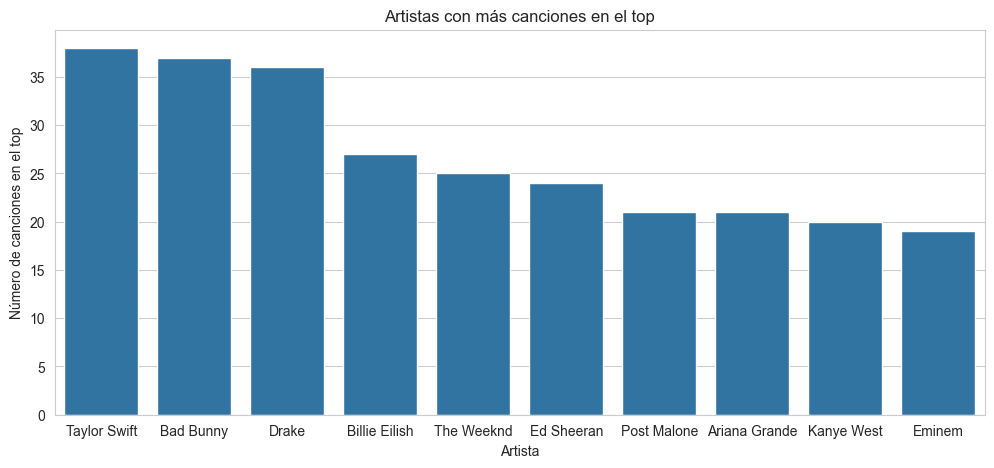

In [199]:
top_artistas=df_mas_streams['Artist'].value_counts().head(10)
plt.figure(figsize=(12,5))

sns.barplot(x=top_artistas.index, y=top_artistas.values)

plt.title("Artistas con más canciones en el top")
plt.xlabel("Artista")
plt.ylabel("Número de canciones en el top")

plt.show()

In [200]:
cols_artistas = ['Streams', 'Daily', 'As lead', 'Solo', 'As feature']

for col in cols_artistas:
    df_artistas[col] = df_artistas[col].astype(str).str.replace(',', '', regex=False)

for col in cols_artistas:
    df_artistas[col] = pd.to_numeric(df_artistas[col], errors='coerce')

In [201]:
cols_escuchas = ['Listeners', 'Daily Trend', 'PkListeners']

for col in cols_escuchas:
    df_escuchas[col] = df_escuchas[col].astype(str).str.replace(',', '', regex=False)

for col in cols_escuchas:
    df_escuchas[col] = pd.to_numeric(df_escuchas[col], errors='coerce')

In [202]:
df_merge = pd.merge(df_artistas, df_escuchas, on='Artist', how='inner')

In [203]:
df_merge.head()

,Artist,Streams,Daily,As lead,Solo,As feature,Listeners,Daily Trend,Peak,PkListeners
0,Drake,85041.3,50.775,57252.6,32681.6,27788.7,75371611,-67013,6,76391086
1,Bad Bunny,67533.0,44.820,40969.6,23073.0,26563.4,76162057,-199052,3,83950570
2,Taylor Swift,57859.0,85.793,55566.7,50425.7,2292.4,101003302,889,2,101003302
3,The Weeknd,53665.2,44.437,42673.3,31164.2,10991.9,107592328,-138880,1,113034886
4,Ed Sheeran,47907.7,17.506,42767.9,33917.0,5139.8,76475126,-68137,2,87934910


Relación entre streams y listeners

Este gráfico permite observar si existe una relación entre el número de reproducciones y la cantidad de oyentes de un artista.

Se utiliza escala logarítmica para mejorar la interpretación de valores muy grandes.

Text(0.5, 1.0, 'Relación entre Streams y Listeners (Top 50 artistas)')

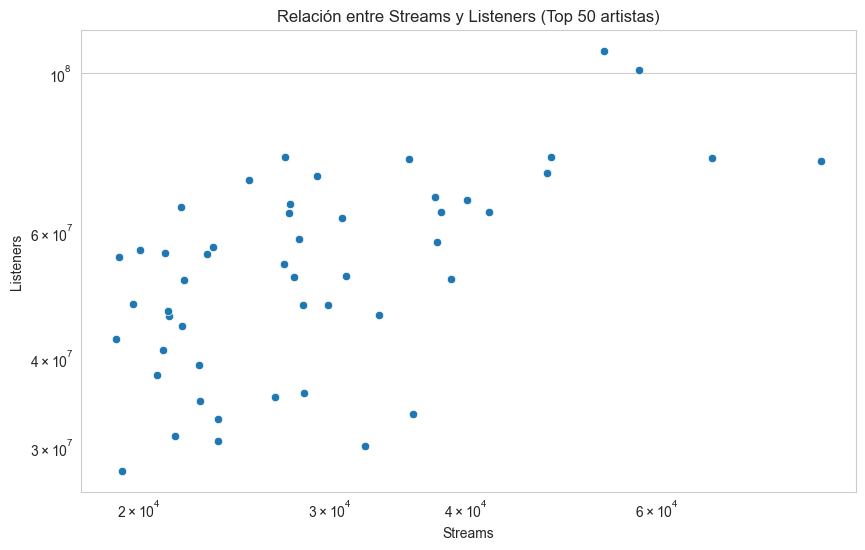

In [204]:
top_artists = df_merge.sort_values(by='Streams', ascending=False).head(50)

plt.figure(figsize=(10,6))

sns.scatterplot(data=top_artists, x='Streams', y='Listeners')

plt.xscale('log')
plt.yscale('log')

plt.title("Relación entre Streams y Listeners (Top 50 artistas)")

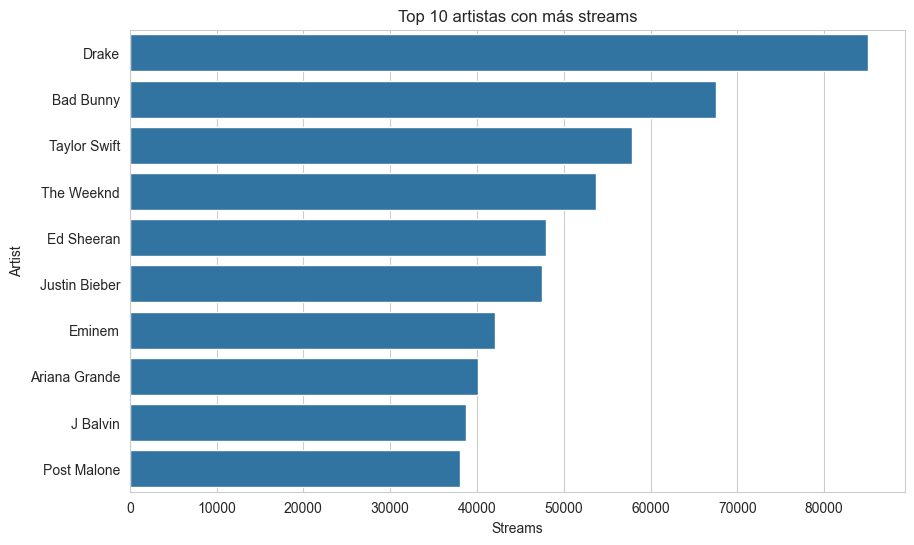

In [205]:
top_stream_artists = df_artistas.sort_values(by='Streams', ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(data=top_stream_artists, x='Streams', y='Artist')

plt.title("Top 10 artistas con más streams")

plt.show()

In [207]:
df_merge[['Streams','Listeners']].corr()

,Streams,Listeners
Streams,1.000000,0.839121
Listeners,0.839121,1.000000


In [208]:
df_merge[['Solo','As lead','As feature','Streams']].corr()

,Solo,As lead,As feature,Streams
Solo,1.000000,0.927811,0.325667,0.816539
As lead,0.927811,1.000000,0.504380,0.940450
As feature,0.325667,0.504380,1.000000,0.767869
Streams,0.816539,0.940450,0.767869,1.000000
